# 5 — Estabilidade da geração KernelSynth e TimePFN

## Resumo

Este experimento adapta o diagnóstico de estabilidade do Notebook 4 aos geradores baseados em processos gaussianos usados por KernelSynth e TimePFN. As mesmas janelas de 96, 192 e 384 pontos e o mesmo limiar de magnitude \(\lvert x_t\rvert>100\) são mantidos para tornar os resultados comparáveis.

Esses geradores não executam uma recorrência a partir de condições iniciais. Portanto, uma excedência de amplitude representa uma realização extrema da distribuição amostrada, e não uma prova de instabilidade dinâmica. O notebook separa:

1. validade numérica das matrizes de covariância;
2. valores não finitos durante a geração;
3. excedências do limiar de amplitude;
4. efeito da mistura convexa do LMC-Synth;
5. dependência entre canais correlacionados e independentes.

O conjunto finito avaliado contém os 33 kernels básicos do código oficial e 20 composições determinísticas. O LMC-Synth é sondado com parâmetros explicitamente declarados, porque os valores usados para produzir o corpus original do TimePFN não são publicados como uma configuração executável.

## 1. Configuração completa e reprodutibilidade

A maior trajetória é gerada uma única vez e os horizontes menores são seus prefixos. Cada mecanismo e trajetória recebe uma semente derivada somente da semente raiz e de índices estáveis; outras sementes existentes no programa do usuário não afetam o experimento.

In [1]:
from __future__ import annotations

from pathlib import Path
import importlib.metadata
import json
import platform
import subprocess
import sys
import time

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "tsfmxai").exists():
            return candidate
    raise RuntimeError("Repository root not found.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SOURCE_ROOT = PROJECT_ROOT / "src"
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from tsfmxai.generators import retained_kernel_cases, stable_factor
from tsfmxai.generators.kernel_synth import draw_from_factor

ROOT_SEED = 20261005
SERIES_LENGTH = 384
HORIZONS = (96, 192, 384)
TRAJECTORIES_PER_MECHANISM = 32
AMPLITUDE_LIMIT = 100.0
COMPARISON_HORIZON = 192
REFERENCE_INNOVATION_STD = 0.05
NEAR_ZERO_RADIUS = 3.0 * REFERENCE_INNOVATION_STD
NEAR_ZERO_TAIL_STEPS = 24

KERNEL_COMPOSITION_COUNT = 20
LMC_MECHANISM_COUNT = 64
LMC_CHANNELS = 8
WEIBULL_SHAPE = 1.5
WEIBULL_SCALE = 3.0
DIRICHLET_MIN = 0.1
DIRICHLET_MAX = 2.0

configuration = {
    "root_seed": ROOT_SEED,
    "series_length": SERIES_LENGTH,
    "horizons": list(HORIZONS),
    "trajectories_per_mechanism": TRAJECTORIES_PER_MECHANISM,
    "amplitude_limit": AMPLITUDE_LIMIT,
    "comparison_horizon": COMPARISON_HORIZON,
    "near_zero_comparison": {
        "absolute_radius": NEAR_ZERO_RADIUS,
        "required_final_steps_inside_radius": NEAR_ZERO_TAIL_STEPS,
        "requires_passing_amplitude_test": True,
        "copied_from_notebook_4_innovation_std": REFERENCE_INNOVATION_STD,
    },
    "kernel_composition_count": KERNEL_COMPOSITION_COUNT,
    "lmc_mechanism_count": LMC_MECHANISM_COUNT,
    "lmc_channels": LMC_CHANNELS,
    "weibull_shape": WEIBULL_SHAPE,
    "weibull_scale": WEIBULL_SCALE,
    "dirichlet_min": DIRICHLET_MIN,
    "dirichlet_max": DIRICHLET_MAX,
}
print(json.dumps(configuration, indent=2))

{
  "root_seed": 20261005,
  "series_length": 384,
  "horizons": [
    96,
    192,
    384
  ],
  "trajectories_per_mechanism": 32,
  "amplitude_limit": 100.0,
  "comparison_horizon": 192,
  "near_zero_comparison": {
    "absolute_radius": 0.15000000000000002,
    "required_final_steps_inside_radius": 24,
    "requires_passing_amplitude_test": true,
    "copied_from_notebook_4_innovation_std": 0.05
  },
  "kernel_composition_count": 20,
  "lmc_mechanism_count": 64,
  "lmc_channels": 8,
  "weibull_shape": 1.5,
  "weibull_scale": 3.0,
  "dirichlet_min": 0.1,
  "dirichlet_max": 2.0
}


**O que foi feito.** A célula localiza a biblioteca do projeto e declara todos os parâmetros que determinam o experimento. O limiar de 100 é apenas um diagnóstico comum com o Notebook 4; ele não redefine uma amostra gaussiana extrema como divergência recursiva.

## Comparação metodológica com o Notebook 4

O Notebook 5 executa o **mesmo núcleo de triagem empírica em horizonte finito**, mas não copia toda a avaliação do Notebook 4, porque os objetos gerados são diferentes. A comparação exata é:

| Aspecto | Notebook 4 — AST recorrente | Notebook 5 — KernelSynth/TimePFN | Relação |
|---|---|---|---|
| Horizontes | 96, 192 e 384 passos | 96, 192 e 384 pontos | Igual |
| Pareamento temporal | Mesma semente faz horizontes curtos repetirem o prefixo da trajetória longa | Uma trajetória de 384 pontos é gerada e seus prefixos são reutilizados | Equivalente |
| Unidade experimental | Cada AST é simulada uma vez para cada limite de condição inicial | Cada kernel ou mistura produz várias trajetórias e, no caso multivariado, vários canais | Diferente; adequado ao caráter estocástico do GP |
| Execução do teste | A recorrência é avaliada passo a passo, interrompida ao falhar e registra o passo da explosão | O vetor gaussiano completo é amostrado e seus prefixos são inspecionados | Mesma classificação final, sem curva de tempo até a falha no Notebook 5 |
| Falha numérica | Valor não finito | Valor não finito | Igual |
| Limite de amplitude | Explosão quando $\lvert x_t\rvert>100$ | Excedência quando $\lvert x_t\rvert>100$ | Mesmo cálculo, interpretação diferente |
| Resumo estatístico | Frequência e intervalo de Wilson de 95\% | Frequência e intervalo de Wilson de 95\% | Igual |
| Condições iniciais | Cinco limites para a história inicial | Não existem condições iniciais recursivas | Específico da AST |
| Colapso para zero/constância | Mede contração da recorrência em relação ao ruído de inovação | Não calculado, pois uma amostra de GP não converge por recorrência e sua escala depende do kernel | Específico da AST |
| Diagnóstico estrutural | Operadores, multiplicações, parâmetros e equivalência algébrica das árvores | PSD/fatoração das covariâncias, mistura convexa e correlação entre canais | Substituído por diagnósticos próprios do gerador |

Portanto, os notebooks respondem à mesma pergunta operacional — *a geração produz valores numericamente válidos e amplitudes aceitáveis até cada horizonte?* — usando o mesmo critério básico. O Notebook 4 também investiga estabilidade de uma dinâmica recursiva; o Notebook 5 investiga validade numérica e extremos de uma distribuição gaussiana finita. Chamar ambos de uma prova única de estabilidade matemática misturaria essas duas noções.

## 2. Mecanismos avaliados e fatoração das covariâncias

KernelSynth fornece as covariâncias latentes. Para cada matriz, verificamos se uma Cholesky sem regularização funciona e depois usamos a fatoração robusta da biblioteca. Os mecanismos LMC correlacionados sorteiam número de latentes, kernels e pesos de mistura. A variante independente sorteia um kernel por canal e usa cada processo diretamente.

In [2]:
build_started = time.perf_counter()
kernel_cases = retained_kernel_cases(
    global_seed=ROOT_SEED,
    length=SERIES_LENGTH,
    composition_count=KERNEL_COMPOSITION_COUNT,
)

kernel_factors = []
covariance_rows = []
for case_index, case in enumerate(kernel_cases):
    matrix = np.asarray(case["covariance"], dtype=float)
    symmetric = (matrix + matrix.T) / 2.0
    scale = max(float(np.mean(np.diag(symmetric))), 1.0)

    try:
        np.linalg.cholesky(symmetric)
        raw_cholesky_success = True
    except np.linalg.LinAlgError:
        raw_cholesky_success = False

    eigenvalues = np.linalg.eigvalsh(symmetric)
    factor = stable_factor(symmetric)
    reconstructed = factor @ factor.T
    delta = reconstructed - symmetric
    diagonal_delta = np.diag(delta)
    off_diagonal_delta = delta - np.diag(diagonal_delta)
    relative_off_diagonal_error = float(np.max(np.abs(off_diagonal_delta)) / scale)
    factorization_mode = (
        "jittered_cholesky"
        if relative_off_diagonal_error <= 1e-7
        else "eigenvalue_clipping"
    )

    kernel_factors.append(factor)
    covariance_rows.append({
        "case_index": case_index,
        "mechanism": case["id"],
        "category": case["category"],
        "family": case["family"],
        "raw_cholesky_success": raw_cholesky_success,
        "finite_covariance": bool(np.isfinite(symmetric).all()),
        "minimum_eigenvalue": float(eigenvalues[0]),
        "maximum_eigenvalue": float(eigenvalues[-1]),
        "psd_within_tolerance": bool(
            eigenvalues[0] >= -1e-8 * max(abs(float(eigenvalues[-1])), 1.0)
        ),
        "factorization_mode": factorization_mode,
        "relative_diagonal_addition": float(max(np.median(diagonal_delta) / scale, 0.0)),
        "relative_reconstruction_error": float(
            np.linalg.norm(delta, ord="fro")
            / max(np.linalg.norm(symmetric, ord="fro"), 1e-12)
        ),
        "minimum_variance": float(np.min(np.diag(symmetric))),
        "maximum_variance": float(np.max(np.diag(symmetric))),
    })

lmc_mechanisms = []
for mechanism_index in range(LMC_MECHANISM_COUNT):
    rng = np.random.default_rng(np.random.SeedSequence([ROOT_SEED, 200, mechanism_index]))
    weibull_draw = float(rng.weibull(WEIBULL_SHAPE))
    latent_count = int(np.clip(
        np.rint(WEIBULL_SCALE * weibull_draw + 1),
        max(2, LMC_CHANNELS // 20),
        LMC_CHANNELS,
    ))
    dirichlet_concentration = float(rng.uniform(DIRICHLET_MIN, DIRICHLET_MAX))
    latent_indices = rng.integers(0, len(kernel_cases), size=latent_count)
    independent_indices = rng.integers(0, len(kernel_cases), size=LMC_CHANNELS)
    mixing = rng.dirichlet(
        dirichlet_concentration * np.ones(latent_count),
        size=LMC_CHANNELS,
    )
    lmc_mechanisms.append({
        "mechanism_index": mechanism_index,
        "mechanism": f"lmc_{mechanism_index + 1:03d}",
        "latent_count": latent_count,
        "dirichlet_concentration": dirichlet_concentration,
        "latent_indices": latent_indices,
        "independent_indices": independent_indices,
        "mixing": mixing,
    })

build_seconds = time.perf_counter() - build_started
covariance_diagnostics = pd.DataFrame(covariance_rows)
lmc_configuration = pd.DataFrame([
    {
        "mechanism": item["mechanism"],
        "latent_count": item["latent_count"],
        "dirichlet_concentration": item["dirichlet_concentration"],
    }
    for item in lmc_mechanisms
])

print(f"KernelSynth mechanisms: {len(kernel_cases)}")
print(f"TimePFN mechanisms per mode: {len(lmc_mechanisms)}")
print(f"Covariance construction and diagnosis: {build_seconds:.3f} s")
display(lmc_configuration.describe())

KernelSynth mechanisms: 53
TimePFN mechanisms per mode: 64
Covariance construction and diagnosis: 1.716 s


,latent_count,dirichlet_concentration
count,64.000000,64.000000
mean,3.406250,1.063169
std,1.540138,0.505200
min,2.000000,0.141426
25%,2.000000,0.626278
50%,3.000000,1.128564
75%,4.000000,1.399117
max,8.000000,1.964404


**O que foi feito.** Os kernels são fatorados uma vez e reutilizados em várias trajetórias. O LMC usa um conjunto finito e reproduzível de mecanismos construídos a partir desse banco; os parâmetros Weibull e Dirichlet pertencem a este experimento e ficam registrados explicitamente.

## 3. Estabilidade numérica das covariâncias

Matrizes positivas semidefinidas podem ser singulares e, por isso, falhar em uma Cholesky direta mesmo quando definem um processo gaussiano válido. O diagnóstico separa essa situação de matrizes não finitas ou genuinamente incompatíveis com a tolerância numérica.

In [3]:
covariance_summary = covariance_diagnostics.groupby(
    ["category", "factorization_mode"], dropna=False
).agg(
    mechanisms=("mechanism", "size"),
    raw_cholesky_successes=("raw_cholesky_success", "sum"),
    finite_covariances=("finite_covariance", "sum"),
    psd_within_tolerance=("psd_within_tolerance", "sum"),
    minimum_eigenvalue=("minimum_eigenvalue", "min"),
    maximum_variance=("maximum_variance", "max"),
    maximum_relative_reconstruction_error=("relative_reconstruction_error", "max"),
)

assert covariance_diagnostics["finite_covariance"].all()
assert covariance_diagnostics["psd_within_tolerance"].all()
assert all(np.isfinite(factor).all() for factor in kernel_factors)

display(covariance_summary)
print(
    "Cholesky sem regularização:",
    f"{covariance_diagnostics['raw_cholesky_success'].mean():.1%}",
)
print(
    "Maior erro relativo de reconstrução:",
    f"{covariance_diagnostics['relative_reconstruction_error'].max():.3e}",
)

,,mechanisms,raw_cholesky_successes,finite_covariances,psd_within_tolerance,minimum_eigenvalue,maximum_variance,maximum_relative_reconstruction_error
category,factorization_mode,,,,,,,
base,jittered_cholesky,33,2,33,33,-1.596609e-11,101.0,9.999998e-10
composite,jittered_cholesky,20,11,20,20,-1.935735e-12,103.0,9.999998e-10


Cholesky sem regularização: 24.5%
Maior erro relativo de reconstrução: 1.000e-09


**O que foi feito.** A tabela informa quantas covariâncias aceitam Cholesky direta e confirma que todas são finitas e positivas semidefinidas dentro da tolerância. A necessidade de jitter em kernels degenerados é uma questão numérica, não uma explosão da série.

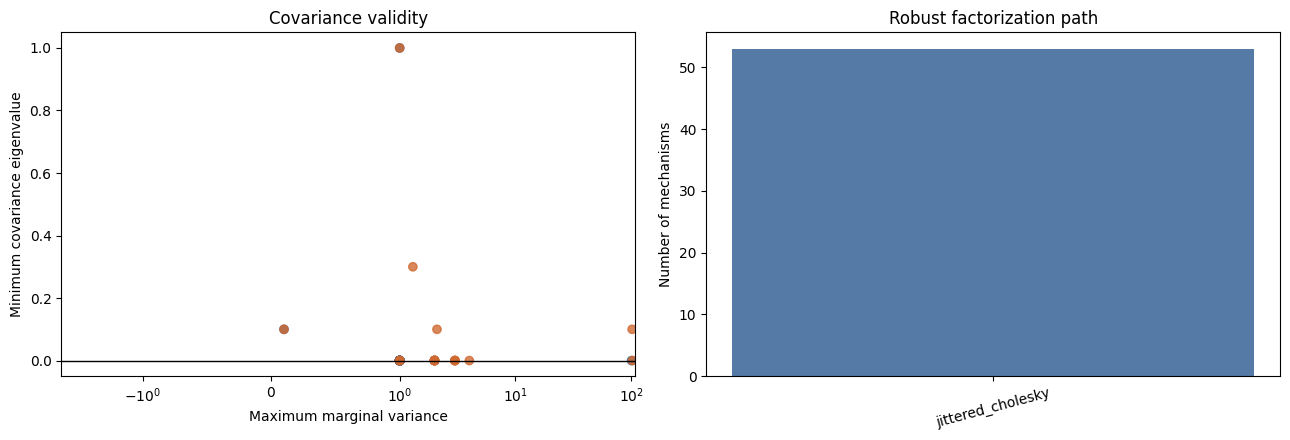

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

colors = covariance_diagnostics["category"].map({"base": "#35618f", "composite": "#cf6a32"})
axes[0].scatter(
    covariance_diagnostics["maximum_variance"],
    covariance_diagnostics["minimum_eigenvalue"],
    c=colors,
    alpha=0.8,
)
axes[0].axhline(0.0, color="black", linewidth=1)
axes[0].set_xscale("symlog", linthresh=1.0)
axes[0].set_xlabel("Maximum marginal variance")
axes[0].set_ylabel("Minimum covariance eigenvalue")
axes[0].set_title("Covariance validity")

mode_counts = covariance_diagnostics["factorization_mode"].value_counts()
axes[1].bar(mode_counts.index, mode_counts.values, color="#547aa5")
axes[1].set_ylabel("Number of mechanisms")
axes[1].set_title("Robust factorization path")
axes[1].tick_params(axis="x", rotation=15)

fig.tight_layout()
plt.show()

**O que foi feito.** O primeiro gráfico relaciona a maior variância marginal com o menor autovalor. O segundo mostra qual caminho numérico foi necessário para produzir uma fatoração utilizável.

## 4. Geração das trajetórias e classificação de estabilidade

Para KernelSynth, cada mecanismo produz várias realizações independentes. Para o LMC correlacionado, funções latentes são combinadas por pesos Dirichlet. Para o modo independente, cada canal recebe sua própria função latente. Os horizontes menores reutilizam os prefixos da mesma trajetória completa.

In [5]:
def trajectory_statistics(values: np.ndarray, horizon: int) -> dict:
    prefix = np.asarray(values[:horizon], dtype=float)
    finite = bool(np.isfinite(prefix).all())
    if not finite:
        return {
            "finite": False,
            "exceeds_amplitude_limit": False,
            "stable_under_test": False,
            "near_zero": False,
            "zero_tail_peak_abs": np.nan,
            "peak_abs": np.inf,
            "rms": np.nan,
            "maximum_step_change": np.nan,
        }
    peak_abs = float(np.max(np.abs(prefix)))
    exceeds = peak_abs > AMPLITUDE_LIMIT
    tail = prefix[-min(NEAR_ZERO_TAIL_STEPS, len(prefix)):]
    zero_tail_peak_abs = float(np.max(np.abs(tail)))
    near_zero = (not exceeds) and zero_tail_peak_abs <= NEAR_ZERO_RADIUS
    return {
        "finite": True,
        "exceeds_amplitude_limit": exceeds,
        "stable_under_test": not exceeds,
        "near_zero": near_zero,
        "zero_tail_peak_abs": zero_tail_peak_abs,
        "peak_abs": peak_abs,
        "rms": float(np.sqrt(np.mean(prefix**2))),
        "maximum_step_change": (
            float(np.max(np.abs(np.diff(prefix)))) if len(prefix) > 1 else 0.0
        ),
    }


representatives: dict[str, dict] = {}


def update_representative(
    generator: str,
    mechanism: str,
    trajectory_index: int,
    channel: int,
    values: np.ndarray,
) -> None:
    peak = float(np.max(np.abs(values)))
    current = representatives.get(generator)
    if current is None or peak > current["peak_abs"]:
        representatives[generator] = {
            "mechanism": mechanism,
            "trajectory_index": trajectory_index,
            "channel": channel,
            "peak_abs": peak,
            "values": np.asarray(values, dtype=float).copy(),
        }


def mean_absolute_off_diagonal_correlation(channels_by_time: np.ndarray) -> float:
    centered = channels_by_time - channels_by_time.mean(axis=1, keepdims=True)
    norms = np.linalg.norm(centered, axis=1)
    valid = norms > 1e-12
    centered = centered[valid]
    norms = norms[valid]
    if len(norms) < 2:
        return np.nan
    correlation = (centered @ centered.T) / np.outer(norms, norms)
    values = correlation[np.triu_indices(len(norms), k=1)]
    return float(np.mean(np.abs(values)))


generation_started = time.perf_counter()
trajectory_rows = []
lmc_pair_rows = []
convex_bound_violations = 0

for case_index, (case, factor) in enumerate(zip(kernel_cases, kernel_factors)):
    rng = np.random.default_rng(np.random.SeedSequence([ROOT_SEED, 300, case_index]))
    draws = draw_from_factor(factor, TRAJECTORIES_PER_MECHANISM, rng)
    for trajectory_index, values in enumerate(draws):
        update_representative("KernelSynth", case["id"], trajectory_index, 0, values)
        for horizon in HORIZONS:
            trajectory_rows.append({
                "generator": "KernelSynth",
                "mechanism": case["id"],
                "trajectory": trajectory_index,
                "channel": 0,
                "horizon": horizon,
                **trajectory_statistics(values, horizon),
            })

for mechanism in lmc_mechanisms:
    mechanism_index = mechanism["mechanism_index"]
    correlated_rng = np.random.default_rng(
        np.random.SeedSequence([ROOT_SEED, 400, mechanism_index])
    )
    latent_draws = np.stack([
        draw_from_factor(
            kernel_factors[int(case_index)],
            TRAJECTORIES_PER_MECHANISM,
            correlated_rng,
        )
        for case_index in mechanism["latent_indices"]
    ], axis=1)
    correlated = np.einsum("cl,nlt->nct", mechanism["mixing"], latent_draws)

    pointwise_latent_bound = np.max(np.abs(latent_draws), axis=1)[:, None, :]
    convex_bound_violations += int(np.count_nonzero(
        np.abs(correlated) > pointwise_latent_bound + 1e-9
    ))

    independent_rng = np.random.default_rng(
        np.random.SeedSequence([ROOT_SEED, 500, mechanism_index])
    )
    independent = np.stack([
        draw_from_factor(
            kernel_factors[int(case_index)],
            TRAJECTORIES_PER_MECHANISM,
            independent_rng,
        )
        for case_index in mechanism["independent_indices"]
    ], axis=1)

    for trajectory_index in range(TRAJECTORIES_PER_MECHANISM):
        latent_peak = float(np.max(np.abs(latent_draws[trajectory_index])))
        correlated_peak = float(np.max(np.abs(correlated[trajectory_index])))
        lmc_pair_rows.append({
            "mechanism": mechanism["mechanism"],
            "trajectory": trajectory_index,
            "latent_count": mechanism["latent_count"],
            "dirichlet_concentration": mechanism["dirichlet_concentration"],
            "correlated_mean_abs_correlation": mean_absolute_off_diagonal_correlation(
                correlated[trajectory_index]
            ),
            "independent_mean_abs_correlation": mean_absolute_off_diagonal_correlation(
                independent[trajectory_index]
            ),
            "correlated_to_latent_peak_ratio": (
                correlated_peak / latent_peak if latent_peak > 0 else 0.0
            ),
            "correlated_peak": correlated_peak,
            "independent_peak": float(np.max(np.abs(independent[trajectory_index]))),
        })

        for generator, channels in (
            ("TimePFN LMC-Synth", correlated[trajectory_index]),
            ("TimePFN independent", independent[trajectory_index]),
        ):
            for channel, values in enumerate(channels):
                update_representative(
                    generator,
                    mechanism["mechanism"],
                    trajectory_index,
                    channel,
                    values,
                )
                for horizon in HORIZONS:
                    trajectory_rows.append({
                        "generator": generator,
                        "mechanism": mechanism["mechanism"],
                        "trajectory": trajectory_index,
                        "channel": channel,
                        "horizon": horizon,
                        **trajectory_statistics(values, horizon),
                    })

generation_seconds = time.perf_counter() - generation_started
trajectory_metrics = pd.DataFrame(trajectory_rows)
lmc_pairs = pd.DataFrame(lmc_pair_rows)

expected_rows = (
    len(kernel_cases) * TRAJECTORIES_PER_MECHANISM
    + 2 * LMC_MECHANISM_COUNT * TRAJECTORIES_PER_MECHANISM * LMC_CHANNELS
) * len(HORIZONS)
assert len(trajectory_metrics) == expected_rows
assert convex_bound_violations == 0

print(f"Series-horizon avaliadas: {len(trajectory_metrics):,}")
print(f"Tempo de geração e diagnóstico: {generation_seconds:.3f} s")
print(f"Violações do limite convexo do LMC: {convex_bound_violations}")

Series-horizon avaliadas: 103,392
Tempo de geração e diagnóstico: 5.166 s
Violações do limite convexo do LMC: 0


**O que foi feito.** A célula gera todas as trajetórias, calcula métricas por horizonte e verifica diretamente a propriedade convexa do LMC: nenhum canal misturado pode ultrapassar, no mesmo instante, o maior módulo de suas funções latentes.

## 5. Frequência de valores extremos por gerador e horizonte

A taxa principal conta séries-canal que apresentam valor não finito ou ultrapassam o limiar de amplitude. Intervalos de Wilson de 95% mostram a incerteza binomial da taxa observada. Para permitir a comparação posterior, também aplicamos literalmente a definição de proximidade de zero do Notebook 4: os 24 pontos finais devem permanecer em $[-0{,}15,0{,}15]$ e a trajetória deve ter passado pelo teste de amplitude.

In [6]:
stability_summary = trajectory_metrics.groupby(
    ["generator", "horizon"]
).agg(
    evaluated_series=("stable_under_test", "size"),
    non_finite=("finite", lambda values: int((~values).sum())),
    amplitude_exceedances=("exceeds_amplitude_limit", "sum"),
    stable_under_test=("stable_under_test", "sum"),
    stability_rate=("stable_under_test", "mean"),
    near_zero_count=("near_zero", "sum"),
    near_zero_rate=("near_zero", "mean"),
    median_zero_tail_peak_abs=("zero_tail_peak_abs", "median"),
    median_peak_abs=("peak_abs", "median"),
    p95_peak_abs=("peak_abs", lambda values: float(np.quantile(values, 0.95))),
    maximum_peak_abs=("peak_abs", "max"),
    median_rms=("rms", "median"),
    median_maximum_step_change=("maximum_step_change", "median"),
).reset_index()

stability_summary["failure_count"] = (
    stability_summary["non_finite"]
    + stability_summary["amplitude_exceedances"]
)
stability_summary["failure_rate"] = (
    stability_summary["failure_count"]
    / stability_summary["evaluated_series"]
)
stability_summary["near_zero_rate_among_stable"] = (
    stability_summary["near_zero_count"]
    / stability_summary["stable_under_test"].replace(0, np.nan)
)

z = 1.959963984540054
n = stability_summary["evaluated_series"].to_numpy(dtype=float)
p = stability_summary["failure_rate"].to_numpy(dtype=float)
center = (p + z*z/(2*n)) / (1 + z*z/n)
half = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / (1 + z*z/n)
stability_summary["failure_wilson_95_low"] = center - half
stability_summary["failure_wilson_95_high"] = center + half

display(stability_summary)

,generator,horizon,evaluated_series,non_finite,amplitude_exceedances,stable_under_test,stability_rate,near_zero_count,near_zero_rate,median_zero_tail_peak_abs,median_peak_abs,p95_peak_abs,maximum_peak_abs,median_rms,median_maximum_step_change,failure_count,failure_rate,near_zero_rate_among_stable,failure_wilson_95_low,failure_wilson_95_high
0,KernelSynth,96,1696,0,0,1696,1.0,47,0.027712,1.500571,1.762840,5.094302,35.110417,0.975365,0.524767,0,0.0,0.027712,0.0,0.002260
1,KernelSynth,192,1696,0,0,1696,1.0,53,0.031250,1.522238,1.836805,5.557663,35.882001,0.988321,0.532219,0,0.0,0.031250,0.0,0.002260
2,KernelSynth,384,1696,0,0,1696,1.0,45,0.026533,1.528672,1.911723,5.882060,35.882001,0.999698,0.535671,0,0.0,0.026533,0.0,0.002260
3,TimePFN LMC-Synth,96,16384,0,0,16384,1.0,167,0.010193,1.221152,1.440147,4.960124,30.245145,0.708382,0.904742,0,0.0,0.010193,0.0,0.000234
4,TimePFN LMC-Synth,192,16384,0,0,16384,1.0,153,0.009338,1.222645,1.538122,5.275993,31.201022,0.712490,0.976779,0,0.0,0.009338,0.0,0.000234
5,TimePFN LMC-Synth,384,16384,0,0,16384,1.0,146,0.008911,1.238492,1.654255,5.735856,32.104007,0.729665,1.035079,0,0.0,0.008911,0.0,0.000234
6,TimePFN independent,96,16384,0,0,16384,1.0,479,0.029236,1.415595,1.601546,4.606752,39.613077,0.946761,0.364892,0,0.0,0.029236,0.0,0.000234
7,TimePFN independent,192,16384,0,0,16384,1.0,413,0.025208,1.409330,1.691552,4.886605,42.861433,0.960010,0.368699,0,0.0,0.025208,0.0,0.000234
8,TimePFN independent,384,16384,0,0,16384,1.0,365,0.022278,1.438661,1.791101,5.265110,42.861433,0.978710,0.372506,0,0.0,0.022278,0.0,0.000234


**O que foi feito.** O resumo apresenta separadamente valores não finitos, excedências de amplitude e caudas próximas de zero. A coluna stable_under_test significa apenas que a trajetória passou pelos critérios declarados neste experimento; near_zero descreve a janela final observada e não prova convergência do processo.

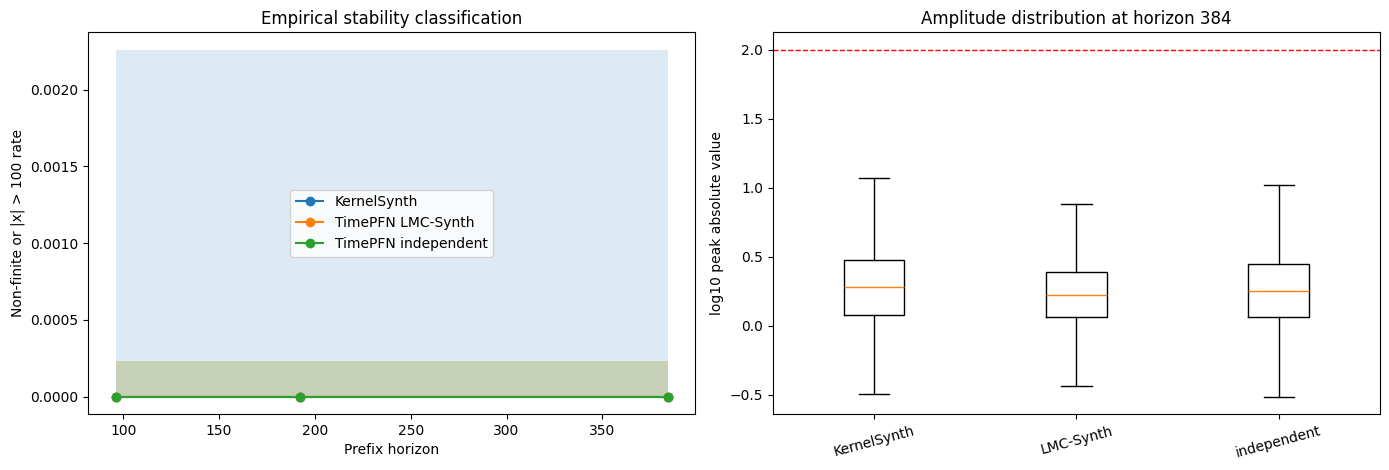

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

for generator, group in stability_summary.groupby("generator"):
    axes[0].plot(
        group["horizon"],
        group["failure_rate"],
        marker="o",
        label=generator,
    )
    axes[0].fill_between(
        group["horizon"],
        group["failure_wilson_95_low"],
        group["failure_wilson_95_high"],
        alpha=0.15,
    )
axes[0].set_xlabel("Prefix horizon")
axes[0].set_ylabel("Non-finite or |x| > 100 rate")
axes[0].set_title("Empirical stability classification")
axes[0].legend()

maximum_horizon = max(HORIZONS)
plot_data = []
plot_labels = []
for generator, group in trajectory_metrics[
    trajectory_metrics["horizon"].eq(maximum_horizon)
].groupby("generator"):
    plot_data.append(np.log10(np.maximum(group["peak_abs"].to_numpy(), 1e-12)))
    plot_labels.append(generator.replace("TimePFN ", ""))
axes[1].boxplot(plot_data, tick_labels=plot_labels, showfliers=False)
axes[1].axhline(np.log10(AMPLITUDE_LIMIT), color="red", linestyle="--", linewidth=1)
axes[1].set_ylabel("log10 peak absolute value")
axes[1].set_title(f"Amplitude distribution at horizon {maximum_horizon}")
axes[1].tick_params(axis="x", rotation=15)

fig.tight_layout()
plt.show()

**O que foi feito.** O gráfico da esquerda mostra como a classificação muda ao observar prefixos maiores. O boxplot compara a distribuição de amplitudes e marca o limiar de 100 em vermelho.

## 6. Efeito da mistura LMC em relação aos canais independentes

Além da amplitude, o objetivo do LMC é produzir dependência entre canais. Comparamos a correlação absoluta média fora da diagonal e verificamos quanto o maior valor observado após a mistura representa do maior valor das latentes usadas.

,metric,LMC correlated,independent channels
0,mean absolute cross-channel correlation,0.737976,0.112988
1,trajectory peak,2.451169,4.338668


Maior razão pico_correlacionado / pico_latente: 1.000000
Violações da combinação convexa: 0


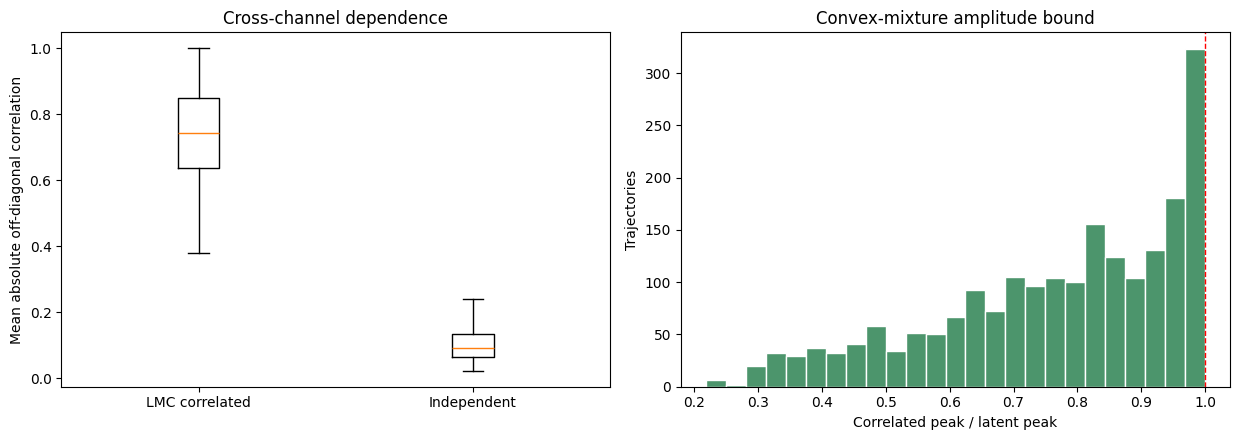

In [8]:
lmc_comparison = pd.DataFrame({
    "metric": [
        "mean absolute cross-channel correlation",
        "trajectory peak",
    ],
    "LMC correlated": [
        float(lmc_pairs["correlated_mean_abs_correlation"].mean()),
        float(lmc_pairs["correlated_peak"].median()),
    ],
    "independent channels": [
        float(lmc_pairs["independent_mean_abs_correlation"].mean()),
        float(lmc_pairs["independent_peak"].median()),
    ],
})
display(lmc_comparison)
print(
    "Maior razão pico_correlacionado / pico_latente:",
    f"{lmc_pairs['correlated_to_latent_peak_ratio'].max():.6f}",
)
print("Violações da combinação convexa:", convex_bound_violations)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
axes[0].boxplot(
    [
        lmc_pairs["correlated_mean_abs_correlation"].dropna(),
        lmc_pairs["independent_mean_abs_correlation"].dropna(),
    ],
    tick_labels=["LMC correlated", "Independent"],
    showfliers=False,
)
axes[0].set_ylabel("Mean absolute off-diagonal correlation")
axes[0].set_title("Cross-channel dependence")

axes[1].hist(
    lmc_pairs["correlated_to_latent_peak_ratio"],
    bins=25,
    color="#4c956c",
    edgecolor="white",
)
axes[1].axvline(1.0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Correlated peak / latent peak")
axes[1].set_ylabel("Trajectories")
axes[1].set_title("Convex-mixture amplitude bound")

fig.tight_layout()
plt.show()

**O que foi feito.** A primeira comparação verifica se o LMC produz a dependência entre canais esperada. A segunda confirma empiricamente o limite de amplitude decorrente dos pesos não negativos que somam um.

## 7. Trajetórias mais extremas observadas

A trajetória com maior módulo em cada modo é mostrada para tornar o critério de amplitude inspecionável. Essas figuras são exemplos extremos dentro da configuração executada, não amostras típicas.

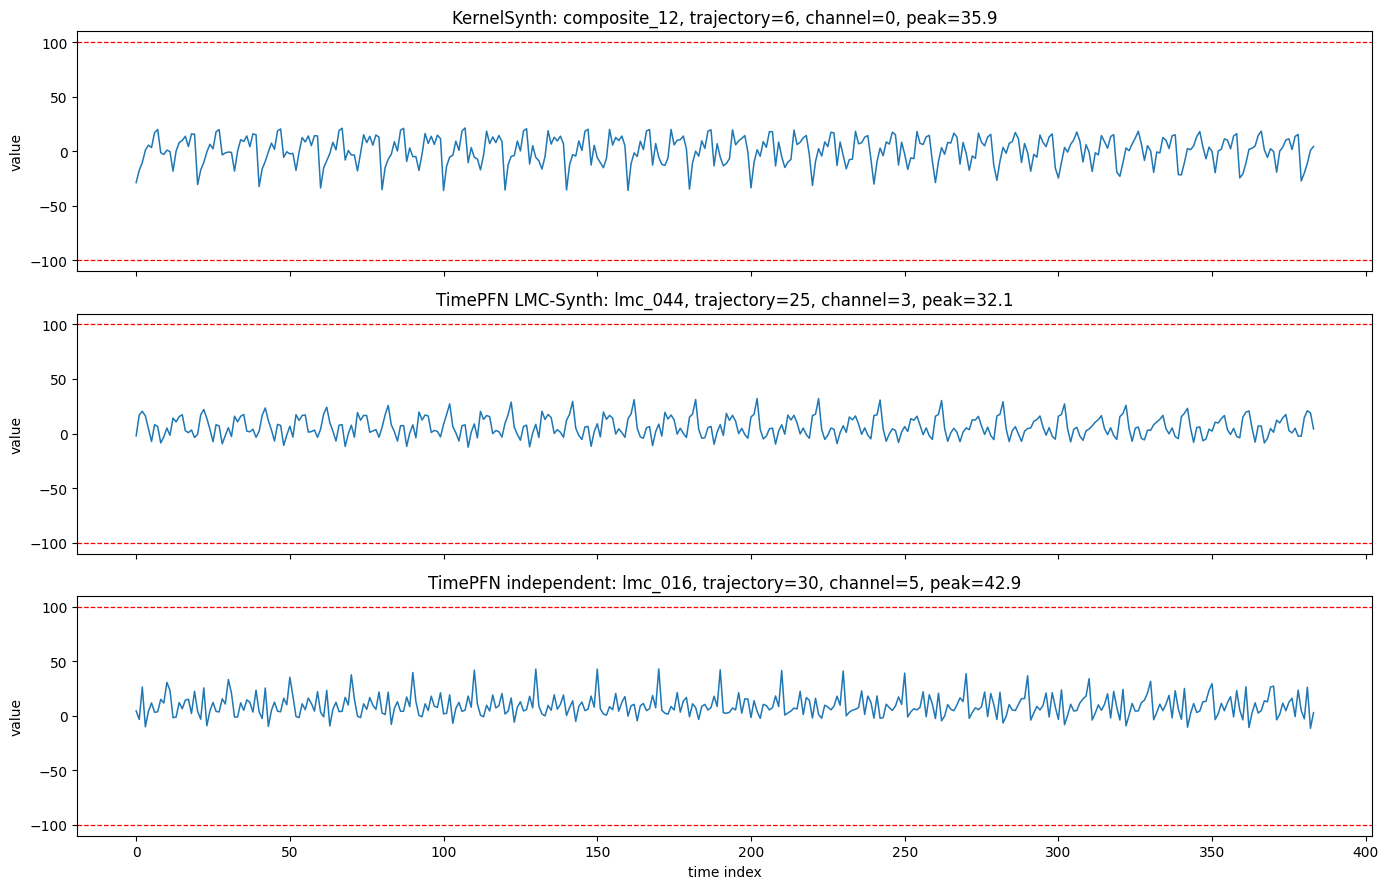

In [9]:
fig, axes = plt.subplots(len(representatives), 1, figsize=(14, 9), sharex=True)
if len(representatives) == 1:
    axes = [axes]

for axis, (generator, item) in zip(axes, representatives.items()):
    axis.plot(item["values"], linewidth=1.1)
    axis.axhline(AMPLITUDE_LIMIT, color="red", linestyle="--", linewidth=0.9)
    axis.axhline(-AMPLITUDE_LIMIT, color="red", linestyle="--", linewidth=0.9)
    axis.set_ylabel("value")
    axis.set_title(
        f"{generator}: {item['mechanism']}, trajectory={item['trajectory_index']}, "
        f"channel={item['channel']}, peak={item['peak_abs']:.3g}"
    )
axes[-1].set_xlabel("time index")
fig.tight_layout()
plt.show()

**O que foi feito.** Cada linha mostra o caso de maior amplitude encontrado para KernelSynth, LMC-Synth correlacionado e canais independentes, sempre com os limites \(+100\) e \(-100\) visíveis.

## 8. Quais mecanismos concentram as maiores amplitudes?

A tabela final de diagnóstico ordena mecanismos pelo maior pico observado no horizonte completo. Ela ajuda a identificar kernels ou misturas que merecem uma análise posterior com mais trajetórias.

In [10]:
maximum_horizon_metrics = trajectory_metrics[
    trajectory_metrics["horizon"].eq(max(HORIZONS))
]
extreme_mechanisms = maximum_horizon_metrics.groupby(
    ["generator", "mechanism"]
).agg(
    evaluated_channels=("peak_abs", "size"),
    maximum_peak_abs=("peak_abs", "max"),
    p95_peak_abs=("peak_abs", lambda values: float(np.quantile(values, 0.95))),
    amplitude_exceedance_rate=("exceeds_amplitude_limit", "mean"),
).reset_index().sort_values(
    ["maximum_peak_abs", "amplitude_exceedance_rate"],
    ascending=False,
)

kernel_formula_lookup = {
    case["id"]: case["formula"]
    for case in kernel_cases
}
extreme_mechanisms["kernel_formula"] = extreme_mechanisms["mechanism"].map(
    kernel_formula_lookup
)
display(extreme_mechanisms.head(15))

,generator,mechanism,evaluated_channels,maximum_peak_abs,p95_peak_abs,amplitude_exceedance_rate,kernel_formula
132,TimePFN independent,lmc_016,256,42.861433,24.284003,0.0,NaN
148,TimePFN independent,lmc_032,256,38.584090,23.897396,0.0,NaN
11,KernelSynth,composite_12,32,35.882001,30.048262,0.0,"(((((ExpSineSquared(length_scale=1, periodicit..."
127,TimePFN independent,lmc_011,256,33.012379,23.753377,0.0,NaN
130,TimePFN independent,lmc_014,256,32.392547,9.287313,0.0,NaN
174,TimePFN independent,lmc_058,256,32.383665,8.745294,0.0,NaN
157,TimePFN independent,lmc_041,256,32.350241,24.715359,0.0,NaN
96,TimePFN LMC-Synth,lmc_044,256,32.104007,23.333083,0.0,NaN
126,TimePFN independent,lmc_010,256,27.862529,13.528481,0.0,NaN
117,TimePFN independent,lmc_001,256,26.976769,12.648482,0.0,NaN


**O que foi feito.** A ordenação distingue se as excedências estão espalhadas pelo prior ou concentradas em poucas composições. A fórmula é exibida quando o mecanismo corresponde diretamente a um caso KernelSynth.

## 9. Comparação quantitativa com o Notebook 4

A comparação usa o horizonte de 192 pontos e os mesmos limites absolutos. **Explodiu/extremo** significa valor não finito ou $\lvert x_t\rvert>100$. **Cauda próxima de zero** significa que os 24 últimos pontos ficaram em $[-0{,}15,0{,}15]$ e que a trajetória não explodiu. O resultado executado do Notebook 4 é lido diretamente de seu registro experimental, evitando copiar números manualmente.

No Notebook 4, cada linha corresponde às mesmas 5.000 ASTs sob um limite diferente para a condição inicial. No Notebook 5, a unidade contada é uma trajetória univariada do KernelSynth ou um canal de uma trajetória multivariada do TimePFN. As contagens brutas têm denominadores diferentes; por isso a tabela também apresenta percentuais. Para os GPs, uma cauda dentro da faixa apenas descreve os pontos observados e não significa convergência assintótica para zero.

,source,process,setting,evaluated_units,exploded_or_extreme_count,near_zero_count,neither_count,exploded_or_extreme_percent,near_zero_percent
0,Notebook 4,recurrent AST,initial |x| <= 0,5000,2366,563,2071,47.32,11.260000
1,Notebook 4,recurrent AST,initial |x| <= 0.1,5000,2369,563,2068,47.38,11.260000
2,Notebook 4,recurrent AST,initial |x| <= 0.5,5000,2401,562,2037,48.02,11.240000
3,Notebook 4,recurrent AST,initial |x| <= 1,5000,2487,522,1991,49.74,10.440000
4,Notebook 4,recurrent AST,initial |x| <= 2,5000,2713,384,1903,54.26,7.680000
5,Notebook 5,KernelSynth,GP draw / channel,1696,0,53,1643,0.00,3.125000
6,Notebook 5,TimePFN LMC-Synth,GP draw / channel,16384,0,153,16231,0.00,0.933838
7,Notebook 5,TimePFN independent,GP draw / channel,16384,0,413,15971,0.00,2.520752


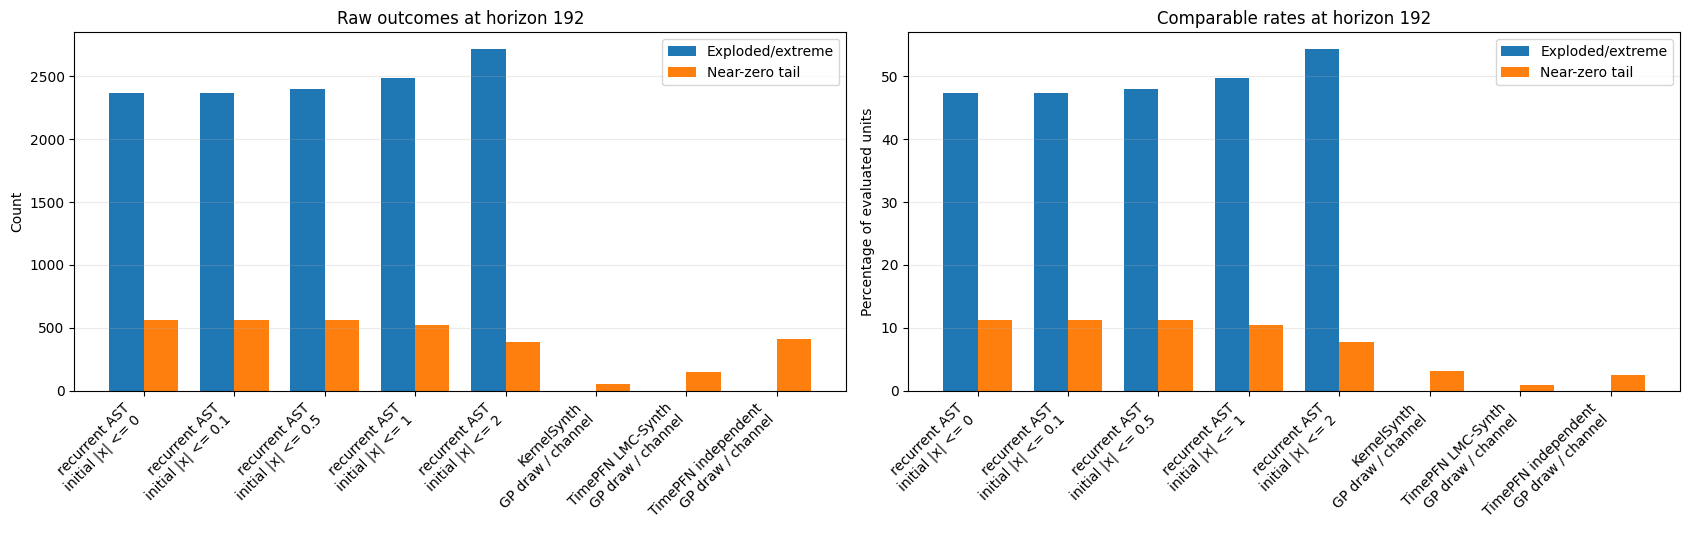

In [11]:
NOTEBOOK_4_ID = "abstract_syntax_tree_004_large_scale_stability_equivalence"
NOTEBOOK_4_PATH = PROJECT_ROOT / "experiments" / "abstract_syntax_tree" / "4_large_scale_stability_and_equivalence.ipynb"


def load_executed_experiment_record(path: Path, experiment_id: str) -> dict:
    notebook = json.loads(path.read_text(encoding="utf-8"))
    for cell in reversed(notebook["cells"]):
        for output in reversed(cell.get("outputs", [])):
            if output.get("output_type") != "stream":
                continue
            payload = output.get("text", "")
            if isinstance(payload, list):
                payload = "".join(payload)
            try:
                candidate = json.loads(payload)
            except (json.JSONDecodeError, TypeError):
                continue
            if candidate.get("experiment_id") == experiment_id:
                return candidate
    raise RuntimeError(f"Executed record {experiment_id!r} not found in {path}.")


notebook_4_record = load_executed_experiment_record(NOTEBOOK_4_PATH, NOTEBOOK_4_ID)
notebook_4_outcomes = notebook_4_record["metrics"]["outcomes_by_horizon_and_input_limit"][str(COMPARISON_HORIZON)]
notebook_4_sample_count = int(notebook_4_record["configuration"]["sample_count"])

comparison_rows = []
for initial_bound, outcome in sorted(notebook_4_outcomes.items(), key=lambda item: float(item[0])):
    failures = int(outcome["count"])
    near_zero = int(outcome["near_zero_count"])
    comparison_rows.append({
        "source": "Notebook 4",
        "process": "recurrent AST",
        "setting": f"initial |x| <= {float(initial_bound):g}",
        "evaluated_units": notebook_4_sample_count,
        "exploded_or_extreme_count": failures,
        "near_zero_count": near_zero,
    })

notebook_5_reference = trajectory_metrics[
    trajectory_metrics["horizon"].eq(COMPARISON_HORIZON)
]
for generator, group in notebook_5_reference.groupby("generator", sort=False):
    failures = int(((~group["finite"]) | group["exceeds_amplitude_limit"]).sum())
    comparison_rows.append({
        "source": "Notebook 5",
        "process": generator,
        "setting": "GP draw / channel",
        "evaluated_units": int(len(group)),
        "exploded_or_extreme_count": failures,
        "near_zero_count": int(group["near_zero"].sum()),
    })

notebook_comparison = pd.DataFrame(comparison_rows)
notebook_comparison["neither_count"] = (
    notebook_comparison["evaluated_units"]
    - notebook_comparison["exploded_or_extreme_count"]
    - notebook_comparison["near_zero_count"]
)
notebook_comparison["exploded_or_extreme_percent"] = (
    100.0 * notebook_comparison["exploded_or_extreme_count"]
    / notebook_comparison["evaluated_units"]
)
notebook_comparison["near_zero_percent"] = (
    100.0 * notebook_comparison["near_zero_count"]
    / notebook_comparison["evaluated_units"]
)
display(notebook_comparison)

labels = [
    f"{row.process}\n{row.setting}"
    for row in notebook_comparison.itertuples(index=False)
]
positions = np.arange(len(notebook_comparison))
width = 0.38
fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
axes[0].bar(positions - width/2, notebook_comparison["exploded_or_extreme_count"], width, label="Exploded/extreme")
axes[0].bar(positions + width/2, notebook_comparison["near_zero_count"], width, label="Near-zero tail")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Raw outcomes at horizon {COMPARISON_HORIZON}")
axes[0].legend()

axes[1].bar(positions - width/2, notebook_comparison["exploded_or_extreme_percent"], width, label="Exploded/extreme")
axes[1].bar(positions + width/2, notebook_comparison["near_zero_percent"], width, label="Near-zero tail")
axes[1].set_ylabel("Percentage of evaluated units")
axes[1].set_title(f"Comparable rates at horizon {COMPARISON_HORIZON}")
axes[1].legend()
for axis in axes:
    axis.set_xticks(positions, labels, rotation=45, ha="right")
    axis.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

**O que foi feito.** A tabela confronta contagens e proporções sob definições numéricas idênticas. As cinco linhas da AST não são cinco conjuntos independentes: elas reutilizam os mesmos mecanismos com condições iniciais progressivamente maiores. As linhas de KernelSynth e TimePFN contam realizações ou canais e, por isso, devem ser comparadas principalmente pelas proporções e pela interpretação específica de cada gerador.

## 10. Registro completo do experimento

A célula seguinte reúne pergunta, hipótese, configuração, proveniência, política de sementes, métricas, limitações e comando de reprodução. Ela é o registro único do notebook executado.

In [12]:
def git_output(*arguments: str) -> str | None:
    try:
        return subprocess.check_output(
            ["git", *arguments],
            cwd=PROJECT_ROOT,
            text=True,
            stderr=subprocess.DEVNULL,
        ).strip()
    except (subprocess.CalledProcessError, FileNotFoundError):
        return None


def json_records(frame: pd.DataFrame) -> list[dict]:
    return json.loads(frame.to_json(orient="records"))


package_versions = {
    name: importlib.metadata.version(name)
    for name in ["numpy", "pandas", "matplotlib", "scikit-learn", "scipy"]
}

maximum_horizon_summary = stability_summary[
    stability_summary["horizon"].eq(max(HORIZONS))
].set_index("generator")
notebook_5_comparison_rows = notebook_comparison[
    notebook_comparison["source"].eq("Notebook 5")
]
near_zero_comparison_text = ", ".join(
    f"{row.process}: {row.near_zero_count}/{row.evaluated_units}"
    for row in notebook_5_comparison_rows.itertuples(index=False)
)

scientific_summary = (
    f"All {len(kernel_cases)} retained KernelSynth covariance mechanisms were finite and PSD within tolerance; "
    f"{covariance_diagnostics['raw_cholesky_success'].mean():.1%} accepted an unregularized Cholesky factorization. "
    f"At horizon {max(HORIZONS)}, failure rates were "
    f"{maximum_horizon_summary.loc['KernelSynth', 'failure_rate']:.2%} for KernelSynth, "
    f"{maximum_horizon_summary.loc['TimePFN LMC-Synth', 'failure_rate']:.2%} for correlated LMC-Synth, and "
    f"{maximum_horizon_summary.loc['TimePFN independent', 'failure_rate']:.2%} for independent channels. "
    f"The mean absolute cross-channel correlation was "
    f"{lmc_pairs['correlated_mean_abs_correlation'].mean():.3f} after LMC mixing and "
    f"{lmc_pairs['independent_mean_abs_correlation'].mean():.3f} for independent channels. "
    f"No convex-mixture amplitude-bound violations were observed. "
    f"At horizon {COMPARISON_HORIZON}, near-zero tail counts were {near_zero_comparison_text}. "
    "Magnitude exceedances are distributional extremes, not evidence of recursive dynamical instability."
)

experiment_record = {
    "experiment_id": "abstract_syntax_tree_005_kernelsynth_timepfn_generation_stability",
    "status": "executed",
    "research_question": (
        "Under a shared finite-horizon amplitude criterion, how often do retained KernelSynth mechanisms, "
        "TimePFN LMC-Synth mixtures, and the TimePFN independent-channel variant produce numerical failures "
        "or extreme trajectories, how often do their observed tails remain near zero, and how do those "
        "counts compare with the recurrent-AST experiment?"
    ),
    "hypothesis": (
        "All covariance mechanisms remain numerically generatable after controlled regularization; "
        "convex LMC mixing never exceeds the pointwise latent amplitude bound and produces stronger "
        "cross-channel dependence than independently generated channels."
    ),
    "configuration": configuration,
    "seed_policy": {
        "external_global_rng_used": False,
        "kernel_trajectory_seed": "SeedSequence([ROOT_SEED, 300, case_index])",
        "lmc_correlated_seed": "SeedSequence([ROOT_SEED, 400, mechanism_index])",
        "lmc_independent_seed": "SeedSequence([ROOT_SEED, 500, mechanism_index])",
        "lmc_mechanism_seed": "SeedSequence([ROOT_SEED, 200, mechanism_index])",
        "shorter_horizons_are_prefixes_of_longer_horizons": True,
    },
    "provenance": {
        "implementation": [
            "src/tsfmxai/generators/kernel_synth.py",
            "experiments/abstract_syntax_tree/4_large_scale_stability_and_equivalence.ipynb",
        ],
        "project_head": git_output("rev-parse", "HEAD"),
        "python": sys.version,
        "platform": platform.platform(),
        "packages": package_versions,
    },
    "metrics": {
        "build_seconds": build_seconds,
        "generation_seconds": generation_seconds,
        "covariance_summary": json_records(covariance_summary.reset_index()),
        "stability_by_generator_and_horizon": json_records(stability_summary),
        "lmc_comparison": json_records(lmc_comparison),
        "convex_bound_violations": convex_bound_violations,
        "largest_mechanism_outcomes": json_records(extreme_mechanisms.head(15)),
        "comparison_with_notebook_4_at_horizon_192": json_records(notebook_comparison),
    },
    "scientific_summary": scientific_summary,
    "limitations": [
        "The finite retained kernel pool does not exhaust all possible KernelSynth compositions.",
        "The LMC Weibull and Dirichlet values are declared probe settings, not claimed original TimePFN corpus parameters.",
        "The threshold |x| > 100 is shared with the recurrent-AST experiment but is not a mathematical GP stability criterion.",
        "The shared near-zero threshold is absolute and inherited from Notebook 4; it is not scale-normalized for different GP kernels and does not prove convergence.",
        "The experiment evaluates finite grids up to 384 points; longer grids can change numerical cost and extreme-value frequency.",
    ],
    "reproduction_command": (
        r".\.venv\Scripts\python.exe -m jupyter nbconvert --to notebook --execute "
        r"experiments\abstract_syntax_tree\5_kernelsynth_timepfn_generation_stability.ipynb "
        r"--inplace --ExecutePreprocessor.timeout=2400"
    ),
}

print(json.dumps(experiment_record, indent=2, ensure_ascii=False))

{
  "experiment_id": "abstract_syntax_tree_005_kernelsynth_timepfn_generation_stability",
  "status": "executed",
  "research_question": "Under a shared finite-horizon amplitude criterion, how often do retained KernelSynth mechanisms, TimePFN LMC-Synth mixtures, and the TimePFN independent-channel variant produce numerical failures or extreme trajectories, how often do their observed tails remain near zero, and how do those counts compare with the recurrent-AST experiment?",
  "hypothesis": "All covariance mechanisms remain numerically generatable after controlled regularization; convex LMC mixing never exceeds the pointwise latent amplitude bound and produces stronger cross-channel dependence than independently generated channels.",
  "configuration": {
    "root_seed": 20261005,
    "series_length": 384,
    "horizons": [
      96,
      192,
      384
    ],
    "trajectories_per_mechanism": 32,
    "amplitude_limit": 100.0,
    "comparison_horizon": 192,
    "near_zero_comparison":

**Interpretação do registro.** O experimento testa uma configuração finita, explícita e reproduzível. Ele permite encontrar mecanismos com amplitudes problemáticas e falhas numéricas, mantendo separada a noção de trajetória extrema da estabilidade dinâmica de uma recorrência.